In [3]:
import pandas as pd
import numpy as np
import os
sim = 998
nodes = 9271
c = []
t = []
for i in range(1,sim+1):
    file = f'csv_files/sim_w_comb_{i}/S_U_PEEQ_COORD_{i}.csv'
    if os.path.isfile(file):
        df_c = pd.read_csv(file)
        c.append(df_c)
        df_t = pd.read_csv(f"csv_files/sim_w_comb_{i}/sim_w_comb_{i}.txt")
        t.append(df_t)

In [2]:
!pip install tensorflow

In [4]:
t_df = pd.concat(t)
c_df = pd.concat(c)
c_df = c_df.replace('       NoValue', np.nan)

In [5]:
c_df.columns = c_df.columns.str.lstrip()
t_df.columns = t_df.columns.str.lstrip()

In [6]:
# Output data for the model
y = c_df.iloc[:,16:21]
y = y.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
df_y = pd.DataFrame({'PEEQ':y.iloc[:,0] ,'S-S11':y.iloc[:,1], 'S-S22':y.iloc[:,2], 'S-S33':y.iloc[:,3], 'S-S12':y.iloc[:,4]})

In [7]:
#sim  = len(x_d)

In [8]:

x = t_df.iloc[:,1:]
x_d = x.values
list1 = []
for i in x_d[:,4]:
    i = np.char.replace(i,"]","")
    i = np.char.replace(i," ","")
    i = float(i)
    list1.append(i)
# for j in x_d[:,0]:
#     i = np.char.replace(j,"[","")
#     i = np.char.replace(j," ","")
#     j = float(j)
#     list2.append(i)
x_data = np.zeros((975,5))
x_data[:,0:4] = x_d[:,0:4]
x_data[:,4] = list1
np.shape(x_d)
#x_global = np.zeros(((nodes-1)*sim,5))
x_global = np.zeros((9037275,5))
for i in range(975):
    x_global[(nodes)*i:(nodes)*(i+1),:] = x_data[i,:] 
df_x = pd.DataFrame({'E':x_global[:,0], 'mu':x_global[:,1],'phi':x_global[:,2],'psi':x_global[:,3], 'c':x_global[:,4], 'x':c_df.iloc[:,5],'y':c_df.iloc[:,6]})


In [13]:
#df_x

In [9]:
df_global = pd.concat([df_x, df_y], axis=1)

In [10]:
df_global

,E,mu,phi,psi,c,x,y,PEEQ,S-S11,S-S22,S-S33,S-S12
0,30.0,0.2,20.0,2.0,0.0131,-2500.00,2500.000,NaN,-0.024198,-0.041168,-0.025720,-0.002831
1,30.0,0.2,20.0,2.0,0.0131,-2500.00,0.000,NaN,-0.053829,-0.084719,-0.053438,-0.000252
2,30.0,0.2,20.0,2.0,0.0131,-2500.00,-2500.000,NaN,-0.076216,-0.120091,-0.077969,0.002362
3,30.0,0.2,20.0,2.0,0.0131,0.00,2500.000,NaN,-0.028770,-0.030920,-0.024307,-0.000161
4,30.0,0.2,20.0,2.0,0.0131,0.00,-2500.000,NaN,-0.082632,-0.107417,-0.076870,-0.000174
...,...,...,...,...,...,...,...,...,...,...,...,...
9264,100.0,0.4,45.0,40.5,0.0377,2137.56,-473.618,0.0,-0.040826,-0.133715,-0.040915,0.001648
9265,100.0,0.4,45.0,40.5,0.0377,2048.66,-909.661,0.0,-0.040301,-0.144563,-0.042742,0.001127
9266,100.0,0.4,45.0,40.5,0.0377,2129.95,-927.103,0.0,-0.040568,-0.144578,-0.042763,0.001158
9267,100.0,0.4,45.0,40.5,0.0377,2131.49,-770.993,0.0,-0.040585,-0.140971,-0.042151,0.001543


In [11]:
# df_global.drop(df_global[df_global['S-S11'] == 0].index, inplace = True)
# df_global.drop(df_global[df_global['S-S22'] == 0].index, inplace = True)
# df_global.drop(df_global[df_global['S-S33'] == 0].index, inplace = True)
# df_global.drop(df_global[df_global['S-S12'] == 0].index, inplace = True)
df_global = df_global.fillna({'PEEQ': 0})
df_global = df_global.dropna()

In [14]:
df_global_x = df_global.iloc[:,0:7]

In [17]:
df_global_x.to_csv('Data_x.csv')


In [19]:
df_global.to_csv('Data.csv')

In [21]:
df_global.iloc[:,7:13]

,PEEQ,S-S11,S-S22,S-S33,S-S12
0,0.0,-0.024198,-0.041168,-0.025720,-0.002831
1,0.0,-0.053829,-0.084719,-0.053438,-0.000252
2,0.0,-0.076216,-0.120091,-0.077969,0.002362
3,0.0,-0.028770,-0.030920,-0.024307,-0.000161
4,0.0,-0.082632,-0.107417,-0.076870,-0.000174
...,...,...,...,...,...
9264,0.0,-0.040826,-0.133715,-0.040915,0.001648
9265,0.0,-0.040301,-0.144563,-0.042742,0.001127
9266,0.0,-0.040568,-0.144578,-0.042763,0.001158
9267,0.0,-0.040585,-0.140971,-0.042151,0.001543


In [13]:
data_x = df_global.iloc[:,0:7].values
data_y = df_global.iloc[:,7:13].values

In [18]:
# Spliting test and training
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.05, random_state = 42)


NameError: name 'data_x' is not defined

In [15]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [16]:
import tensorflow as tf
print(tf.__version__)
# Part 2:Building an ANN using keras
#Initializing ANN
ann = tf.keras.models.Sequential()

2.8.0


In [17]:
#Adding the input and first hidden layer, will be adding a dense layer
ann.add(tf.keras.layers.Dense(units = 15,activation = tf.keras.layers.LeakyReLU(alpha=0.01)))

In [18]:
#Adding second hidden layer
ann.add(tf.keras.layers.Dense(units = 13, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
#ann.add(tf.keras.layers.Dense(units = 12, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
#ann.add(tf.keras.layers.Dense(units = 20, activation = 'relu'))
#ann.add(tf.keras.layers.Dense(units = 20, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units = 8, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))
ann.add(tf.keras.layers.Dense(units = 8, activation = tf.keras.layers.LeakyReLU(alpha=0.01)))

In [25]:
#Output Layer
ann.add(tf.keras.layers.Dense(units = 5, activation = 'linear'))

In [26]:
#compling ann
ann.compile(optimizer = 'adam', loss = 'mean_squared_error',metrics = ['accuracy'])

In [27]:
#traing the model
ann.fit(x_train,y_train,batch_size = 128, epochs = 50)

Epoch 1/50
56690/56690 [==============================] - 78s 1ms/step - loss: 4.7051e-04 - accuracy: 0.8043
Epoch 2/50
56690/56690 [==============================] - 76s 1ms/step - loss: 4.1420e-04 - accuracy: 0.8321
Epoch 3/50
56690/56690 [==============================] - 76s 1ms/step - loss: 4.0691e-04 - accuracy: 0.8376
Epoch 4/50
56690/56690 [==============================] - 77s 1ms/step - loss: 4.0223e-04 - accuracy: 0.8379
Epoch 5/50
56690/56690 [==============================] - 77s 1ms/step - loss: 3.9848e-04 - accuracy: 0.8314
Epoch 6/50
56690/56690 [==============================] - 77s 1ms/step - loss: 3.9536e-04 - accuracy: 0.8296
Epoch 7/50
56690/56690 [==============================] - 79s 1ms/step - loss: 3.9246e-04 - accuracy: 0.8315
Epoch 8/50
56690/56690 [==============================] - 78s 1ms/step - loss: 3.9084e-04 - accuracy: 0.8341
Epoch 9/50
56690/56690 [==============================] - 77s 1ms/step - loss: 3.8925e-04 - accuracy: 0.8382
Epoch 10/50
56690/5

In [ ]:
#a1 = ann.predict(sc.transform([[30,0.4,38.75,19.375,0.005,600,2500]]))

In [28]:
def get_data(w):
    import pandas as pd
    import numpy as np
    sim = 1
    nodes = 9270
    c = []
    t = []
    #for i in range(1,sim+1):
    
    df_c = pd.read_csv(f'csv_files1/sim_w_comb_{w}/S_U_PEEQ_COORD_{w}.csv')
    c.append(df_c)
    df_t = pd.read_csv(f'csv_files1/sim_w_comb_{w}/sim_w_comb_{w}.txt')
    t.append(df_t)
    t_df = pd.concat(t)
    c_df = pd.concat(c)
    c_df = c_df.replace('       NoValue', np.nan)
    c_df.columns = c_df.columns.str.lstrip()
    t_df.columns = t_df.columns.str.lstrip()
    # Output data for the model
    y = c_df.iloc[:,16:21]
    y = y.astype({'PEEQ': float,'S-S11':float, 'S-S22':float, 'S-S33':float, 'S-S12':float})
    df_y = pd.DataFrame({'PEEQ':y.iloc[:,0] ,'S-S11':y.iloc[:,1], 'S-S22':y.iloc[:,2], 'S-S33':y.iloc[:,3], 'S-S12':y.iloc[:,4]})
    x = t_df.iloc[:,1:]
    x_d = x.values
    list1 = []
    for i in x_d[:,4]:
        i = np.char.replace(i,"]","")
        i = np.char.replace(i," ","")
        i = float(i)
        list1.append(i)
    # for j in x_d[:,0]:
    #     i = np.char.replace(j,"[","")
    #     i = np.char.replace(j," ","")
    #     j = float(j)
    #     list2.append(i)
    x_data = np.zeros((sim,5))
    x_data[:,0:4] = x_d[:,0:4]
    x_data[:,4] = list1
    np.shape(x_d)
    x_global = np.zeros(((nodes-1)*sim,5))
    for i in range(sim):
        x_global[(nodes)*i:(nodes)*(i+1),:] = x_data[i,:] 
    x_input = pd.DataFrame({'E':x_global[:,0], 'mu':x_global[:,1],'phi':x_global[:,2],'psi':x_global[:,3], 'c':x_global[:,4], 'x':c_df.iloc[:,5],'y':c_df.iloc[:,6]})
    #x_in = np.zeros((nodes-1,7))
    df_global = pd.concat([x_input, df_y], axis=1)
#     df_global.drop(df_global[df_global['S-S11'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S22'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S33'] == 0].index, inplace = True)
#     df_global.drop(df_global[df_global['S-S12'] == 0].index, inplace = True)
    #df_global = df_global.fillna({'PEEQ': 0})
    #dd = df_global.dropna()
    #data_x = df_global.iloc[:,0:7].values
    #data_y = df_global.iloc[:,7:13].values
    
#     x_in = np.zeros((nodes-1,7))
#     for i in range(0,7):
#         x_in[:,i] = x_input.T.iloc[i]
    return(df_global)

    #return {'x': data_x, 'y': data_y }
    #return

In [29]:
output16 = np.zeros((7834,5))
output134 = np.zeros((7834,5))
output198 = np.zeros((7834,5))
output312 = np.zeros((7834,5))
output401 = np.zeros((7834,5))
output632 = np.zeros((7834,5))
output708 = np.zeros((7834,5))
output795 = np.zeros((7834,5))
output866 = np.zeros((7834,5))
output987 = np.zeros((7834,5))
for i in range(0,7834):
    output16[i,:] = ann.predict(sc.transform([get_data(16).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output134[i,:] = ann.predict(sc.transform([get_data(134).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output198[i,:] = ann.predict(sc.transform([get_data(198).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output312[i,:] = ann.predict(sc.transform([get_data(312).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output401[i,:] = ann.predict(sc.transform([get_data(401).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output632[i,:] = ann.predict(sc.transform([get_data(632).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output708[i,:] = ann.predict(sc.transform([get_data(708).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output795[i,:] = ann.predict(sc.transform([get_data(795).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output866[i,:] = ann.predict(sc.transform([get_data(866).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))
    output987[i,:] = ann.predict(sc.transform([get_data(987).fillna({'PEEQ': 0}).dropna().iloc[:,0:7].values.tolist()[i]]))

In [1]:
j = [16,134,198,312,401,632,708,795,866,987]
df_global = get_data(j[9]).fillna({'PEEQ': 0})
dd = df_global.dropna()
data_x1 = df_global.replace(np.nan,0).iloc[:,0:7].values
data_y1 = df_global.replace(np.nan,0).iloc[:,7:13].values
data_X1 = df_global.iloc[:,0:7].values
data_Y1 = df_global.iloc[:,7:13].values
data_x = dd.iloc[:,0:7].values
data_y = dd.iloc[:,7:13].values

NameError: name 'get_data' is not defined

In [60]:

Z = data_y1.tolist()
cord = data_x1.tolist()
s = []
s_out = []
x_cor = []
y_cor = []
error = []
sigma = 1
# sigma = 1(sxx); sigma =2 (syy) ; sigma = 3 (szz)
for i in range(9269):
    temp1 = Z[:][i][sigma]
    s.append(temp1)
    temp2 = cord[:][i][5]
    x_cor.append(temp2)
    temp3 = cord[:][i][6]
    y_cor.append(temp3)
for i in range(7834):
    temp4 = output16[:][i][sigma]
    s_out.append(temp4)
#     e = (abs(s_out[i]-s[i])*100)/abs(s[i])
#     error.append(e)

In [61]:
import pandas as pd
ddi = pd.DataFrame({'x':data_X1[:,5],'y': data_X1[:,6],'s11' : data_Y1[:,1]})
ddf = pd.DataFrame({'x':data_x[:,5], 'y':data_x[:,6], 's11': s_out})
#d_ml = pd.merge(ddi,ddf, how ='inner', on = 'x')
#ddi.isnull().sum()
ddf2 = ddi[ddi['s11'].isna()]
df_ml = pd.concat([ddf,ddf2])
df_ml = df_ml.replace(np.nan,0)
x1_ml = df_ml['x'].tolist()
y1_ml = df_ml['y'].tolist()
s11_out = df_ml['s11'].tolist()

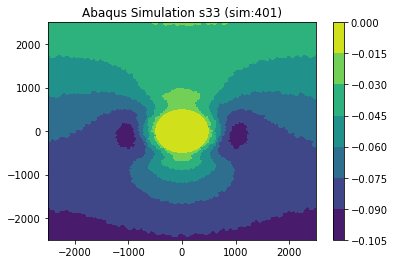

In [62]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

x = np.asarray(x_cor)
y = np.asarray(y_cor)
z = np.asarray(s)
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("Abaqus Simulation s11 (sim:401)")
plt.colorbar()

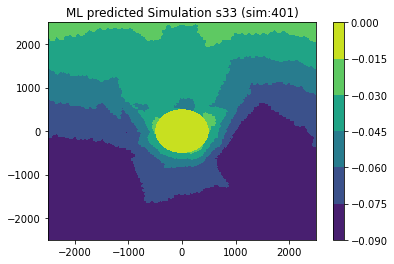

In [63]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt
x = np.asarray(x1_ml)
y = np.asarray(y1_ml)
z = np.asarray(s11_out)
xi = np.linspace(np.min(x), np.max(x), len(x))
yi = np.linspace(np.min(y), np.max(y), len(y))

X,Y= np.meshgrid(xi,yi)
Z = griddata((x, y), z, (X, Y),method='nearest')
plt.contourf(X,Y,Z)
plt.title("ML predicted Simulation s11 (sim:401)")
plt.colorbar()

In [38]:
z

array([-0.00458162, -0.02191786, -0.02967938, ..., -0.02180192,
       -0.02167762, -0.02165786])